#AI4S SCIENTIFIC METHOD FOR OPTIMAL TAX STRUCTURE DISCOVERY
---

##0.REFERENCE

##1.CONTEXT


**Applying the AI for Science Discovery Loop to Personal Tax Strategy**

---

Tax planning is, at its core, a search problem. The tax code is a finite
but combinatorially complex set of rules — brackets, phase-outs, deduction
limits, retirement vehicles, credit cliffs — and the goal is to find the
combination of legal actions that minimises liability for a specific taxpayer
in a specific year. That framing maps precisely onto the **AI for Science
(AI4S)** paradigm: a system that proposes candidate solutions, tests them
against structured evidence, learns from failures, and updates its search
direction accordingly.

This notebook applies that paradigm to a realistic tax planning scenario.
The taxpayer is Alex and Jordan Chen — a dual-income household with W-2
wages, a consulting LLC, rental income, capital gains, under-funded
retirement accounts, and an unrealised loss sitting idle in a brokerage
account. Their situation is not exotic, but it is rich enough that no
single strategy dominates: every action in one area has consequences in
another, and the best overall plan requires reasoning across all of them
simultaneously.

The system that searches for that plan has three components. `TaxOptimizationLoop`
runs one complete research cycle: it generates candidate strategies via
Claude, passes them through a legal validity gate, simulates their tax
impact using a self-contained arithmetic engine, stress-tests the best
strategy under three regulatory scenarios, and produces a structured
feedback diagnosis. `TaxEvaluationAgent` governs multiple rounds of that
loop, accumulating failure context between cycles and deciding — via a
structured Claude call — whether to continue searching or accept the best
result found.

The third component is the most important: `HumanAdvisorAgent`. Claude
plays the role of Margaret Chen, a senior CPA with 25 years of experience
who reviews every AI recommendation before it can proceed. She may approve,
approve with required modifications, or reject outright. Her rationale,
her specific concerns, and her required changes are all fed back into the
next research cycle's hypothesis generation — so the loop learns from
human judgment, not just from numerical performance.

This is the key departure from the algorithmic trading version of AI4S.
In trading, the kill switch is automatic. In tax planning, a human being
carries legal responsibility for every filing, and a human being must
remain the final decision-maker. The architecture is designed around that
constraint, not in spite of it.





---

**Architecture**

```
TaxEvaluationAgent  (governs up to 3 research cycles)
  |
  +--> TaxOptimizationLoop.run()  --> CycleResult
         |                                |
         | generate strategies (Claude)   |
         | simulate tax impact            |
         | legal validity gate (Claude)   |
         | audit risk stress test         |
         | rank by risk-adjusted savings  |
         | get feedback (Claude)          |
                                          |
  +--> HumanAdvisorAgent.review()  <------+
         | Claude plays skeptical CPA
         | APPROVE / APPROVE_WITH_MODS / REJECT
         | provides written rationale
         |
  +--> TaxEvaluationAgent decides:
         CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS
```

| Cell | Content |
|------|---------|
| 1 | Setup |
| 2 | Synthetic tax code |
| 3 | Taxpayer profile |
| 4 | Tax simulation engine |
| 5 | `TaxOptimizationLoop` class |
| 6 | `HumanAdvisorAgent` class |
| 7 | `TaxEvaluationAgent` class |
| 8 | Orchestrator |
| 9 | Final report dashboard |


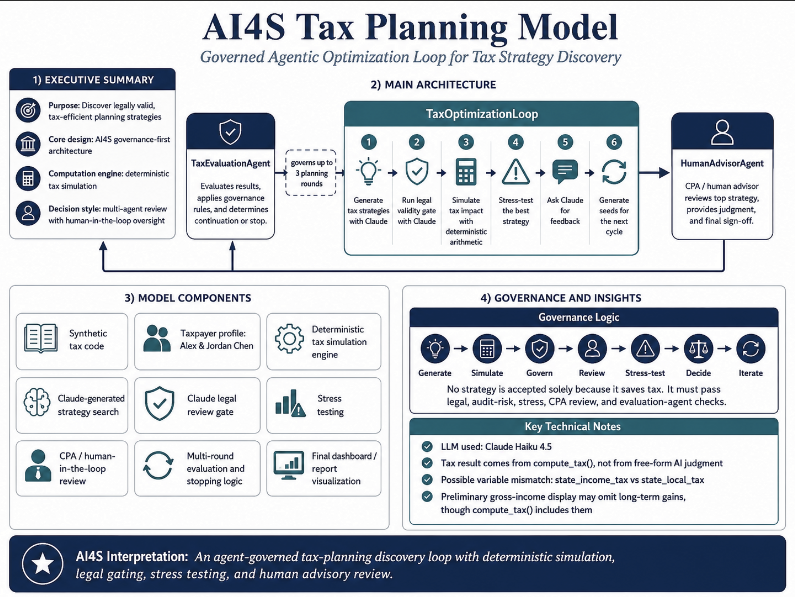

##2.CODE AND IMPLEMENTATION

###2.1.LIBRARIES AND ENVIRONMENT




This cell prepares the notebook’s execution environment. It begins by installing the Anthropic package, which is necessary because the notebook uses Claude as the language model supporting strategy generation, legal review, feedback, CPA simulation, and evaluation decisions. The setup imports standard Python tools such as json, warnings, dataclasses, typing utilities, matplotlib, NumPy, Google Colab userdata, and the Anthropic SDK.

The cell configures matplotlib so that later visualizations are rendered with higher resolution and cleaner plot borders. It suppresses warnings to keep the notebook output readable. This is useful in a teaching or demonstration context because the focus should remain on the model architecture and outputs rather than incidental notebook warnings.

A key operational element is the retrieval of the Anthropic API key through Google Colab’s userdata system. The variable API_KEY obtains the stored credential, CLIENT creates the Anthropic client, and MODEL sets the LLM to `claude-haiku-4-5-20251001`. This means the notebook relies on a relatively lightweight Claude model for repeated agent calls, which is sensible for a multi-step loop where cost and latency matter.

The function `ask_claude(system, user, max_tokens=1200)` is the notebook’s primary LLM interface. It sends a system instruction and user prompt to Claude, receives the response, and returns stripped text. By centralizing Claude calls in this function, the notebook avoids duplicating API code across different agents.

The function `parse_json(raw)` is a defensive helper. Because LLMs sometimes wrap JSON in markdown fences or return minor formatting artifacts, this function cleans common wrappers such as ```json and then attempts to parse the response as JSON. This is essential in agentic workflows because later steps depend on machine-readable outputs, not only natural-language explanations.

Overall, this cell is the infrastructure layer. It establishes the bridge between deterministic Python computation and LLM-driven reasoning. In AI4S terms, it provides the technical substrate for a governed multi-agent loop.

In [2]:
# CELL 1  SETUP
# -----------------------------------------------------------------------
!pip install anthropic --quiet

import json, warnings
from dataclasses import dataclass, field
from typing import Optional
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
from google.colab import userdata
import anthropic

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

API_KEY = userdata.get('ANTHROPIC_API_KEY')
CLIENT  = anthropic.Anthropic(api_key=API_KEY)
MODEL   = 'claude-haiku-4-5-20251001'

def ask_claude(system, user, max_tokens=1200):
    msg = CLIENT.messages.create(
        model=MODEL, max_tokens=max_tokens,
        system=system,
        messages=[{'role': 'user', 'content': user}]
    )
    return msg.content[0].text.strip()

def parse_json(raw):
    clean = raw.strip().replace('```json','').replace('```','')
    return json.loads(clean.strip())

print('Setup complete -- model:', MODEL)

Setup complete -- model: claude-haiku-4-5-20251001


###2.2.SYNTHETIC TAX CODE



This cell defines the fictional tax environment in which the model operates. The object `TAX_CODE` is a structured Python dictionary representing “Synthetic Federal Tax Code v1.0” for tax year 2024. It is not intended to reproduce real tax law. Instead, it creates a sufficiently rich artificial tax system so that strategy search becomes non-trivial and the agentic architecture can be tested safely without making real-world legal claims.

The tax code includes ordinary income brackets for both single filers and married filing jointly. These brackets establish progressive marginal rates, allowing the simulation engine to calculate ordinary income tax in a realistic way. The cell also defines standard deductions for single and married filing jointly taxpayers, creating the choice between standard and itemized deductions later in the tax engine.

Capital gains rules are also included. The code distinguishes long-term capital gains and qualified dividends from ordinary income, with a separate rate schedule. This matters because tax strategies may affect the timing or recognition of gains, and the model needs a way to evaluate whether those changes create savings.

The dictionary also contains rules for the Net Investment Income Tax, self-employment tax, retirement contribution limits, HSA contributions, IRA phaseouts, QBI deductions, itemized deductions, SALT caps, charitable deductions, credits, withholding, estimated tax penalties, AMT-style rules, and audit-risk parameters. Together, these rules allow the notebook to simulate interactions between income, deductions, credits, retirement contributions, business income, capital gains, and risk.

The importance of this cell is that it gives the model a controlled legal universe. Claude can propose strategies, but the deterministic simulator can only evaluate them according to these encoded rules. This separation is central to the AI4S design. The LLM does not invent the tax result; it searches within a predefined formal environment. The synthetic code therefore functions as the rulebook, the sandbox, and the governance boundary for the entire notebook.

In [3]:
# CELL 2  SYNTHETIC TAX CODE
# A self-contained fictional tax system with enough complexity
# to make strategy search non-trivial.
# -----------------------------------------------------------------------

TAX_CODE = {

    'name': 'Synthetic Federal Tax Code v1.0',
    'tax_year': 2024,

    # -- Ordinary income brackets (single / married filing jointly) ------
    'brackets_single': [
        (12_000,  0.10),
        (48_000,  0.18),
        (100_000, 0.26),
        (220_000, 0.34),
        (float('inf'), 0.42),
    ],
    'brackets_mfj': [
        (24_000,  0.10),
        (96_000,  0.18),
        (200_000, 0.26),
        (440_000, 0.34),
        (float('inf'), 0.42),
    ],

    # -- Standard deduction -----------------------------------------------
    'std_deduction_single': 14_000,
    'std_deduction_mfj':    28_000,

    # -- Capital gains rates ----------------------------------------------
    'cap_gains_rates': [
        (44_000,  0.00),   # 0% up to this taxable income (MFJ)
        (492_000, 0.15),   # 15% up to this
        (float('inf'), 0.20),
    ],

    # -- Net Investment Income Tax ----------------------------------------
    'niit_rate':       0.038,
    'niit_threshold_mfj': 250_000,  # applies to lesser of NII or AGI excess

    # -- Alternative Minimum Tax ------------------------------------------
    'amt_rate':        0.26,
    'amt_exemption_mfj':  140_000,
    'amt_phaseout_mfj':   1_000_000,
    'amt_add_backs': ['state_local_tax', 'misc_deductions'],

    # -- Retirement vehicles ----------------------------------------------
    'retirement': {
        '401k':   {'limit': 23_000, 'catch_up_50': 7_500,
                   'deductible': True,  'employer_match': True},
        'ira':    {'limit':  7_000,  'catch_up_50': 1_000,
                   'deductible': 'income_tested', 'phaseout_mfj': (126_000, 146_000)},
        'sep_ira':{'limit_pct': 0.25, 'limit_abs': 69_000,
                   'deductible': True, 'requires_self_employment': True},
        'hsa':    {'limit_family': 8_300, 'deductible': True,
                   'requires_hdhp': True, 'triple_tax_advantage': True},
    },

    # -- Itemizable deductions --------------------------------------------
    'itemizable': {
        'mortgage_interest':  {'limit_principal': 750_000, 'fully_deductible': True},
        'state_local_tax':    {'limit': 10_000, 'amt_addback': True},
        'charitable_cash':    {'agi_limit_pct': 0.60},
        'charitable_noncash': {'agi_limit_pct': 0.30},
        'medical':            {'floor_pct_agi': 0.075},
    },

    # -- Credits ----------------------------------------------------------
    'credits': {
        'child_tax_credit':   {'per_child': 2_000, 'refundable_up_to': 1_600,
                               'phaseout_mfj': (400_000, float('inf'))},
        'child_care_credit':  {'rate': 0.20, 'max_expenses': 6_000},
        'education_credit':   {'max': 2_500, 'phaseout_mfj': (160_000, 180_000)},
        'ev_credit':          {'amount': 7_500, 'income_cap_mfj': 300_000},
    },

    # -- Self-employment --------------------------------------------------
    'se_tax_rate':          0.153,
    'se_tax_deduction_pct': 0.50,   # deduct half of SE tax

    # -- Qualified Business Income deduction (QBI) -----------------------
    'qbi_deduction_pct':    0.20,
    'qbi_wage_limit_pct':   0.50,   # 50% of W2 wages paid by business
    'qbi_phaseout_mfj':     (364_000, 464_000),

    # -- Loss harvesting / carryforward ----------------------------------
    'cap_loss_offset_ordinary': 3_000,  # max ordinary income offset per year
    'cap_loss_carryforward':    True,

    # -- Estimated tax penalty threshold ---------------------------------
    'safe_harbor_pct_prior_year': 1.10,  # 110% of prior year tax
    'underpayment_penalty_rate':  0.05,
}

print('Synthetic Tax Code loaded:')
print(f'  Brackets: 5 tiers, top rate {TAX_CODE["brackets_mfj"][-1][1]:.0%}')
print(f'  Retirement vehicles: {list(TAX_CODE["retirement"].keys())}')
print(f'  Credits: {list(TAX_CODE["credits"].keys())}')
print(f'  AMT rate: {TAX_CODE["amt_rate"]:.0%}  |  QBI deduction: {TAX_CODE["qbi_deduction_pct"]:.0%}')

Synthetic Tax Code loaded:
  Brackets: 5 tiers, top rate 42%
  Retirement vehicles: ['401k', 'ira', 'sep_ira', 'hsa']
  Credits: ['child_tax_credit', 'child_care_credit', 'education_credit', 'ev_credit']
  AMT rate: 26%  |  QBI deduction: 20%


###2.3.THE TAX PROBLEM



This cell defines the client case used throughout the notebook. The taxpayer profile is stored in the `TAXPAYER` dictionary and represents a married filing jointly household named Alex and Jordan Chen. The household includes two dependents, which later affects child tax credits and family-related planning possibilities.

The profile is deliberately detailed. It includes W-2 income for both spouses, freelance income from Alex’s consulting LLC, rental income and rental expenses, qualified dividends, long-term capital gains, short-term capital gains, and unrealized losses. This creates a realistic planning problem because the household has multiple income types, each potentially governed by different tax rules. Ordinary wages, freelance income, rental activity, dividends, short-term gains, long-term gains, and unrealized losses can all interact with deductions, contribution limits, credits, and tax thresholds.

The cell also specifies current retirement contributions, HSA contributions, IRA contributions, charitable giving, mortgage interest, property tax, state income tax, student loan interest, tax preparation fees, withholding, and estimated tax payments. These fields are essential because tax planning usually works through marginal adjustments to existing behavior. The AI does not evaluate a blank household; it evaluates deltas from a realistic baseline.

The profile also contains client preferences and constraints. These include liquidity constraints, audit-risk tolerance, desire for simplicity, and preference for conservative or low-risk planning. These elements are crucial because the best tax strategy is not simply the one with the largest numerical savings. A strategy may save money but still be unsuitable if it requires too much cash, triggers high audit risk, creates complexity, or conflicts with the client’s preferences.

This cell turns the synthetic tax code into a specific advisory problem. The household profile gives the optimization loop something concrete to reason about. In the AI4S architecture, this is the client-state layer: it supplies facts, constraints, and preferences that the simulator and agents must respect.

In [4]:
# CELL 3  TAXPAYER PROFILE
# Meet Alex & Jordan Chen -- a specific household with a real tax problem.
# -----------------------------------------------------------------------

TAXPAYER = {
    'name':           'Alex & Jordan Chen',
    'filing_status':  'mfj',
    'ages':           (44, 41),
    'dependents':     2,          # two children under 17

    # -- Income sources --------------------------------------------------
    'w2_income':          195_000,   # Alex, software engineer
    'spouse_w2':           88_000,   # Jordan, nurse
    'freelance_income':    42_000,   # Alex, consulting LLC (Schedule C)
    'rental_income':       18_000,   # one rental property
    'rental_expenses':     11_500,   # mortgage, maintenance, depreciation
    'qualified_dividends':  4_200,
    'long_term_cap_gains':  28_000,  # sold ETF position
    'short_term_cap_gains':  6_500,  # sold single stock
    'unrealized_losses':   -14_000,  # losing position still held

    # -- Current retirement contributions --------------------------------
    'contrib_401k_alex':   15_000,   # below max ($23k)
    'contrib_401k_jordan':  8_000,   # below max ($23k)
    'contrib_ira':              0,   # not contributing

    # -- Deductions currently taken --------------------------------------
    'mortgage_interest':   22_000,
    'property_tax':         8_500,
    'state_income_tax':     9_200,   # will hit SALT cap
    'charitable_cash':      3_500,
    'mortgage_principal':  580_000,  # well under $750k limit

    # -- Other facts ------------------------------------------------------
    'has_hdhp':            True,     # high-deductible health plan
    'hsa_contrib_current': 2_000,    # below family max ($8,300)
    'has_ev':              False,    # no EV yet
    'business_w2_wages':  35_000,    # wages paid by consulting LLC
    'prior_year_tax':     68_400,    # for safe harbor calculation
    'withholding_ytd':    61_000,    # current withholdings
    'state':              'CA',      # high state tax

    # -- Goals & constraints ---------------------------------------------
    'risk_tolerance':     'moderate',  # willing to use common strategies
    'audit_risk_max':     'low',       # does not want aggressive positions
    'liquidity_needed':   50_000,      # cannot lock up more than this
    'time_horizon':       'this_year', # tax year strategies only
}

# Compute raw AGI (before optimisation) as a baseline
gross_income = (
    TAXPAYER['w2_income'] + TAXPAYER['spouse_w2'] +
    TAXPAYER['freelance_income'] +
    (TAXPAYER['rental_income'] - TAXPAYER['rental_expenses']) +
    TAXPAYER['qualified_dividends'] +
    TAXPAYER['short_term_cap_gains']
)

print('Taxpayer:', TAXPAYER['name'])
print(f'  Filing status : {TAXPAYER["filing_status"].upper()}')
print(f'  Gross income  : ${gross_income:,.0f}')
print(f'  Freelance LLC : ${TAXPAYER["freelance_income"]:,.0f}')
print(f'  Cap gains     : ${TAXPAYER["long_term_cap_gains"]:,.0f} LT + ${TAXPAYER["short_term_cap_gains"]:,.0f} ST')
print(f'  Unrealised L  : ${TAXPAYER["unrealized_losses"]:,.0f}')
print(f'  Current 401k  : ${TAXPAYER["contrib_401k_alex"]+TAXPAYER["contrib_401k_jordan"]:,.0f} (room: ${(23_000-TAXPAYER["contrib_401k_alex"])+(23_000-TAXPAYER["contrib_401k_jordan"]):,.0f} more)')
print(f'  HSA room left : ${TAX_CODE["retirement"]["hsa"]["limit_family"]-TAXPAYER["hsa_contrib_current"]:,.0f}')

Taxpayer: Alex & Jordan Chen
  Filing status : MFJ
  Gross income  : $342,200
  Freelance LLC : $42,000
  Cap gains     : $28,000 LT + $6,500 ST
  Unrealised L  : $-14,000
  Current 401k  : $23,000 (room: $23,000 more)
  HSA room left : $6,300


###2.4.TAX SIMULATION ENGINE



This cell is the computational heart of the notebook. It defines the `TaxResult` dataclass and the `compute_tax()` function. Unlike the Claude-based components, this part of the notebook is pure arithmetic. It does not ask the LLM to estimate tax liability. Instead, it applies the synthetic tax code to the taxpayer profile and returns a structured result.

The `TaxResult` dataclass captures the major outputs of the simulation. It includes gross income, AGI, taxable income, ordinary tax, capital gains tax, NIIT, self-employment tax, AMT, credits, total tax, effective rate, marginal rate, QBI deduction, itemized deductions, balance due, and explanatory notes. This structure is important because it makes the tax result auditable. Rather than returning only one number, the engine produces a decomposed tax calculation.

The `compute_tax()` function accepts a taxpayer dictionary, an optional adjustments dictionary, and an optional tax code dictionary. The adjustments represent the candidate strategy being tested. For example, a strategy may increase retirement contributions, harvest losses, defer freelance income, increase charitable giving, or modify deductible expenses. The helper function `adj()` combines the baseline taxpayer value with the proposed strategy delta.

The engine computes income components, self-employment tax, retirement deductions, IRA deductibility, HSA deductions, AGI, itemized versus standard deductions, QBI deduction, taxable income, ordinary tax, capital gains tax, NIIT, credits, AMT, effective tax rate, marginal tax rate, and balance due. This allows the notebook to compare the baseline tax result against each proposed strategy under consistent rules.

This cell is central to the credibility of the model. Claude may generate ideas, but the tax savings are computed deterministically by `compute_tax()`. That distinction prevents the system from becoming a free-form advisory chatbot. In AI4S terms, this is the formal simulation engine that grounds the agentic loop in reproducible arithmetic.

In [5]:
# CELL 4  TAX SIMULATION ENGINE
# Pure arithmetic -- no Claude calls. Takes a taxpayer dict + a list of
# strategy adjustments and returns a detailed TaxResult.
# -----------------------------------------------------------------------

@dataclass
class TaxResult:
    gross_income:      float = 0
    agi:               float = 0
    taxable_income:    float = 0
    ordinary_tax:      float = 0
    cap_gains_tax:     float = 0
    niit:              float = 0
    se_tax:            float = 0
    amt:               float = 0
    credits_applied:   float = 0
    total_tax:         float = 0
    effective_rate:    float = 0
    marginal_rate:     float = 0
    amt_triggered:     bool  = False
    qbi_deduction:     float = 0
    itemized:          float = 0
    balance_due:       float = 0
    notes:             list  = field(default_factory=list)


def compute_tax(tp: dict, adjustments: dict = None, tc: dict = None) -> TaxResult:
    if tc is None:   tc = TAX_CODE
    if adjustments is None: adjustments = {}
    r = TaxResult()

    # -- apply adjustments (strategies add/subtract from base values) ----
    def adj(key, default=None):
        base = tp.get(key, default if default is not None else 0)
        return base + adjustments.get(key, 0)

    # -- income ----------------------------------------------------------
    w2          = adj('w2_income') + adj('spouse_w2')
    freelance   = max(adj('freelance_income'), 0)
    rental_net  = adj('rental_income') - abs(adj('rental_expenses', tp['rental_expenses']))
    qual_div    = adj('qualified_dividends')
    lt_gains    = adj('long_term_cap_gains')
    st_gains    = adj('short_term_cap_gains')

    r.gross_income = w2 + freelance + rental_net + qual_div + lt_gains + st_gains

    # -- self-employment tax ---------------------------------------------
    r.se_tax = freelance * tc['se_tax_rate']
    se_deduction = r.se_tax * tc['se_tax_deduction_pct']

    # -- retirement contributions ----------------------------------------
    k401 = min(adj('contrib_401k_alex'), tc['retirement']['401k']['limit'])
    k401 += min(adj('contrib_401k_jordan'), tc['retirement']['401k']['limit'])
    sep  = min(freelance * tc['retirement']['sep_ira']['limit_pct'],
               tc['retirement']['sep_ira']['limit_abs'])
    sep  = sep if adjustments.get('use_sep', False) else adj('contrib_sep', 0)
    hsa  = min(adj('hsa_contrib_current'), tc['retirement']['hsa']['limit_family'])
    ira  = adj('contrib_ira', 0)
    # IRA deductibility phaseout
    po_lo, po_hi = tc['retirement']['ira']['phaseout_mfj']
    ira_agi_pre = r.gross_income - se_deduction - k401 - sep
    if ira_agi_pre > po_hi:
        ira_deductible = 0
    elif ira_agi_pre > po_lo:
        ira_deductible = ira * (1 - (ira_agi_pre - po_lo) / (po_hi - po_lo))
    else:
        ira_deductible = ira

    # -- AGI -------------------------------------------------------------
    r.agi = (r.gross_income - se_deduction - k401 - sep
             - hsa - ira_deductible)
    r.agi = max(r.agi, 0)

    # -- QBI deduction (20% of net freelance, subject to wage limit) -----
    qbi_po_lo, qbi_po_hi = tc['qbi_phaseout_mfj']
    if r.agi <= qbi_po_lo:
        qbi_base = freelance * tc['qbi_deduction_pct']
    elif r.agi >= qbi_po_hi:
        qbi_base = 0
    else:
        fade = (r.agi - qbi_po_lo) / (qbi_po_hi - qbi_po_lo)
        qbi_base = freelance * tc['qbi_deduction_pct'] * (1 - fade)
    wage_limit = tp.get('business_w2_wages', 0) * tc['qbi_wage_limit_pct']
    r.qbi_deduction = min(qbi_base, wage_limit)

    # -- Itemised vs standard deduction ----------------------------------
    salt = min(adj('state_local_tax') + adj('property_tax'),
               tc['itemizable']['state_local_tax']['limit'])
    mortgage = min(adj('mortgage_interest'),
                   tc['itemizable']['mortgage_interest']['limit_principal']
                   * 0.04)    # simplified: cap at 4% of principal limit
    charitable = min(adj('charitable_cash'), r.agi * tc['itemizable']['charitable_cash']['agi_limit_pct'])
    r.itemized = salt + mortgage + charitable
    std = tc['std_deduction_mfj']
    deduction = max(r.itemized, std)
    r.notes.append(f"{'Itemised' if r.itemized > std else 'Standard'} deduction: ${deduction:,.0f}")

    # -- Taxable income --------------------------------------------------
    r.taxable_income = max(r.agi - deduction - r.qbi_deduction, 0)

    # -- Ordinary income tax (excluding preferential gains) --------------
    pref_income = qual_div + lt_gains     # taxed at cap gains rates
    ordinary_ti = max(r.taxable_income - pref_income, 0)

    def bracket_tax(income, brackets):
        tax, prev = 0.0, 0.0
        for top, rate in brackets:
            if income <= prev: break
            taxable_in_bracket = min(income, top) - prev
            tax += taxable_in_bracket * rate
            prev = top
        return tax

    r.ordinary_tax = bracket_tax(ordinary_ti, tc['brackets_mfj'])

    # -- Marginal rate ---------------------------------------------------
    prev = 0
    for top, rate in tc['brackets_mfj']:
        if ordinary_ti <= top:
            r.marginal_rate = rate; break
        prev = top

    # -- Capital gains tax -----------------------------------------------
    cg_tax = 0.0; prev_cg = 0.0
    for top, rate in tc['cap_gains_rates']:
        if pref_income <= prev_cg: break
        cg_tax += (min(pref_income, top) - prev_cg) * rate
        prev_cg = top
    r.cap_gains_tax = cg_tax

    # -- NIIT ------------------------------------------------------------
    if r.agi > tc['niit_threshold_mfj']:
        niit_base = min(pref_income, r.agi - tc['niit_threshold_mfj'])
        r.niit = niit_base * tc['niit_rate']

    # -- AMT -------------------------------------------------------------
    amt_addback = salt    # SALT is an AMT add-back
    amt_income = r.agi - deduction + amt_addback - r.qbi_deduction
    amt_exempt  = tc['amt_exemption_mfj']
    amt_base    = max(amt_income - amt_exempt, 0)
    amt_tentative = amt_base * tc['amt_rate']
    r.amt = max(amt_tentative - (r.ordinary_tax + r.cap_gains_tax), 0)
    r.amt_triggered = r.amt > 0

    # -- Credits ---------------------------------------------------------
    ctc = (tc['credits']['child_tax_credit']['per_child']
           * tp.get('dependents', 0))
    po_lo_ctc, po_hi_ctc = tc['credits']['child_tax_credit']['phaseout_mfj']
    if r.agi > po_lo_ctc:
        ctc = max(ctc - ((r.agi - po_lo_ctc) // 1000) * 50, 0)
    r.credits_applied = ctc

    # -- Total tax -------------------------------------------------------
    r.total_tax = max(
        r.ordinary_tax + r.cap_gains_tax + r.niit
        + r.se_tax + r.amt - r.credits_applied,
        0)
    r.effective_rate = r.total_tax / r.gross_income if r.gross_income else 0
    r.balance_due    = r.total_tax - tp.get('withholding_ytd', 0)
    return r


# -- Baseline (no strategies) -------------------------------------------
baseline = compute_tax(TAXPAYER)
print('BASELINE TAX RESULT (no optimization)')
print(f'  Gross income   : ${baseline.gross_income:>12,.0f}')
print(f'  AGI            : ${baseline.agi:>12,.0f}')
print(f'  Taxable income : ${baseline.taxable_income:>12,.0f}')
print(f'  Ordinary tax   : ${baseline.ordinary_tax:>12,.0f}')
print(f'  Cap gains tax  : ${baseline.cap_gains_tax:>12,.0f}')
print(f'  SE tax         : ${baseline.se_tax:>12,.0f}')
print(f'  NIIT           : ${baseline.niit:>12,.0f}')
print(f'  AMT            : ${baseline.amt:>12,.0f}  {"<-- TRIGGERED" if baseline.amt_triggered else ""}')
print(f'  Credits        : ${baseline.credits_applied:>12,.0f}')
print(f'  TOTAL TAX      : ${baseline.total_tax:>12,.0f}')
print(f'  Effective rate : {baseline.effective_rate:>12.1%}')
print(f'  Marginal rate  : {baseline.marginal_rate:>12.1%}')
print(f'  Balance due    : ${baseline.balance_due:>12,.0f}')

BASELINE TAX RESULT (no optimization)
  Gross income   : $     370,200
  AGI            : $     341,987
  Taxable income : $     299,587
  Ordinary tax   : $      65,312
  Cap gains tax  : $           0
  SE tax         : $       6,426
  NIIT           : $       1,224
  AMT            : $           0  
  Credits        : $       4,000
  TOTAL TAX      : $      68,961
  Effective rate :        18.6%
  Marginal rate  :        34.0%
  Balance due    : $       7,961


###2.5.TAX OPTIMIZATION CLASS



This cell defines the main optimization engine of the notebook. It introduces the `TaxCycleResult` dataclass and the `TaxOptimizationLoop` class. Together, they encapsulate one complete research cycle in the tax-planning discovery process.

`TaxCycleResult` stores everything produced during a cycle: the cycle number, generated strategies, simulation results, best strategy, best simulated tax result, baseline tax, best savings, audit risk, legal verdict, stress-test results, fragility flag, feedback verdict, and next-cycle seeds. This is important because it makes every cycle auditable. The model does not merely keep the final answer; it preserves intermediate evidence.

The `TaxOptimizationLoop` class contains the procedural logic for one full optimization round. It begins with a strategy glossary, which tells Claude what adjustment keys are available and what constraints apply. This is a crucial control mechanism. Claude is not allowed to propose arbitrary tax magic; it must express strategies as structured deltas compatible with the deterministic simulator.

The method `generate_strategies()` asks Claude to produce exactly five candidate strategies as JSON. The method `legal_gate()` asks Claude to review whether a proposed strategy is legally valid inside the synthetic tax environment. The method `simulate_all()` applies `compute_tax()` to each strategy, compares the results to baseline tax, and ranks savings. The method `stress_test()` checks whether the best strategy still works under adverse scenarios such as rate increases, deduction caps, or income spikes. The method `get_feedback()` obtains Claude’s reflective assessment, and `generate_seeds()` produces ideas for the next cycle.

The `run()` method orchestrates all of these steps into a single cycle. It prints progress, stores results, and identifies the best available strategy after legal and simulation filtering.

This cell is where the AI4S loop becomes operational. It combines generation, validation, deterministic simulation, ranking, stress testing, feedback, and iteration. The result is a governed discovery process rather than a one-shot recommendation.

In [6]:
# CELL 5  TaxOptimizationLoop CLASS
# Encapsulates one full optimization cycle.
# -----------------------------------------------------------------------

@dataclass
class TaxCycleResult:
    cycle_num:            int
    strategies:           list  = field(default_factory=list)
    simulation_results:   list  = field(default_factory=list)
    best_strategy:        dict  = field(default_factory=dict)
    best_result:          object = None
    baseline_tax:         float = 0
    best_savings:         float = 0
    audit_risk:           str   = 'unknown'
    legal_verdict:        str   = ''
    stress_results:       dict  = field(default_factory=dict)
    fragile:              bool  = True
    feedback_verdict:     str   = ''
    next_seeds:           list  = field(default_factory=list)


class TaxOptimizationLoop:

    STRATEGY_GLOSSARY = (
        'Available adjustments (dict keys for the adjustments parameter):\n'
        '  contrib_401k_alex    increase Alex 401k (max $23,000)\n'
        '  contrib_401k_jordan  increase Jordan 401k (max $23,000)\n'
        '  use_sep              bool -- open SEP-IRA for consulting LLC\n'
        '  hsa_contrib_current  increase HSA (family max $8,300)\n'
        '  contrib_ira          add IRA contributions (max $7,000 each)\n'
        '  short_term_cap_gains reduce by harvesting unrealized losses\n'
        '  long_term_cap_gains  accelerate/defer gains\n'
        '  charitable_cash      increase charitable giving (bunching)\n'
        '  freelance_income     defer/accelerate freelance invoices\n'
        '  rental_expenses      additional deductible improvements\n'
        'Each value is the DELTA from baseline (positive = increase, negative = decrease).\n'
        'Constraints: total liquidity impact <= $50,000. No illegal positions.\n'
    )

    def __init__(self, cycle_num, failure_context=''):
        self.cycle_num = cycle_num
        self.failure_context = failure_context
        self.result = TaxCycleResult(cycle_num=cycle_num,
                                     baseline_tax=baseline.total_tax)

    # -- 1. Generate strategies -----------------------------------------
    def generate_strategies(self):
        fail_block = (
            'IMPORTANT: prior strategies that FAILED legal review or stress test:\n'
            + self.failure_context
            + '\nDo NOT regenerate these. Propose more conservative alternatives.\n'
        ) if self.failure_context else ''

        system = (
            'You are a tax optimization AI applying the AI4S discovery loop. '
            'Generate exactly 5 tax strategies as a JSON array. '
            'Each element: name(str), description(str, 2 sentences), '
            'adjustments(dict of numeric deltas), '
            'rationale(str, <=20 words), '
            'estimated_audit_risk(str: low/medium/high), '
            'liquidity_impact(float, positive=cash out, negative=cash locked up). '
            'Return ONLY the JSON array, no markdown.'
        )
        taxpayer_summary = json.dumps({
            k: v for k, v in TAXPAYER.items()
            if k not in ['name']
        }, indent=2)
        user = (
            fail_block
            + f'Tax code summary:\n'
            + f'  Top bracket: {TAX_CODE["brackets_mfj"][-1][1]:.0%}, '
            + f'  SEP limit: {TAX_CODE["retirement"]["sep_ira"]["limit_abs"]:,}, '
            + f'  QBI deduction: {TAX_CODE["qbi_deduction_pct"]:.0%}\n\n'
            + f'Taxpayer profile:\n{taxpayer_summary}\n\n'
            + f'Baseline total tax: ${baseline.total_tax:,.0f} '
            + f'(effective rate: {baseline.effective_rate:.1%})\n\n'
            + f'Available adjustments:\n{self.STRATEGY_GLOSSARY}\n'
            + 'Generate 5 diverse strategies. Each must be legal, '
            + 'within the liquidity constraint ($50k), and reduce total tax.'
        )
        raw = ask_claude(system, user, max_tokens=1500)
        return parse_json(raw)

    # -- 2. Legal validity gate -----------------------------------------
    def legal_gate(self, strategies):
        system = (
            'You are a tax attorney reviewing proposed strategies against a '
            'synthetic tax code. For each strategy, determine if it is '
            'LEGAL, BORDERLINE, or ILLEGAL under the synthetic code provided. '
            'Return a JSON array with one object per strategy: '
            '{name, verdict(LEGAL/BORDERLINE/ILLEGAL), reason(str, <=15 words)}. '
            'Return ONLY the JSON array.'
        )
        code_summary = json.dumps({
            k: v for k, v in TAX_CODE.items()
            if k in ['retirement','itemizable','credits','qbi_deduction_pct',
                     'cap_loss_offset_ordinary','se_tax_rate']
        }, indent=2)
        user = (
            f'Tax code rules:\n{code_summary}\n\n'
            f'Proposed strategies:\n'
            + json.dumps([{'name': s['name'],
                           'adjustments': s.get('adjustments',{}),
                           'description': s.get('description','')} for s in strategies],
                         indent=2)
        )
        raw = ask_claude(system, user, max_tokens=800)
        verdicts = parse_json(raw)
        return {v['name']: v for v in verdicts}

    # -- 3. Simulate all strategies ------------------------------------
    def simulate_all(self, strategies, legal_verdicts):
        results = []
        for s in strategies:
            verdict = legal_verdicts.get(s['name'], {}).get('verdict', 'LEGAL')
            if verdict == 'ILLEGAL':
                results.append({'strategy': s, 'result': None,
                                'savings': 0, 'legal': False})
                continue
            try:
                adj = s.get('adjustments', {})
                res = compute_tax(TAXPAYER, adj)
                savings = baseline.total_tax - res.total_tax
                results.append({'strategy': s, 'result': res,
                                'savings': savings, 'legal': True,
                                'effective_rate': res.effective_rate,
                                'audit_risk': s.get('estimated_audit_risk','low')})
            except Exception as e:
                results.append({'strategy': s, 'result': None,
                                'savings': 0, 'legal': True, 'error': str(e)})
        return sorted(results, key=lambda x: x['savings'], reverse=True)

    # -- 4. Stress test best strategy ----------------------------------
    def stress_test(self, best_s):
        adj = best_s.get('adjustments', {})

        # A: rate increase -- top bracket rises 4pp
        tc_a = dict(TAX_CODE)
        tc_a['brackets_mfj'] = [(t, r+0.04 if r > 0.30 else r)
                                 for t, r in TAX_CODE['brackets_mfj']]
        res_a = compute_tax(TAXPAYER, adj, tc_a)
        sav_a = baseline.total_tax - res_a.total_tax

        # B: deduction cap -- retirement limit drops 20%
        tc_b = dict(TAX_CODE)
        tc_b['retirement'] = dict(TAX_CODE['retirement'])
        tc_b['retirement']['401k'] = dict(TAX_CODE['retirement']['401k'])
        tc_b['retirement']['401k']['limit'] = int(23_000 * 0.80)
        tc_b['retirement']['sep_ira'] = dict(TAX_CODE['retirement']['sep_ira'])
        tc_b['retirement']['sep_ira']['limit_abs'] = int(69_000 * 0.80)
        res_b = compute_tax(TAXPAYER, adj, tc_b)
        sav_b = baseline.total_tax - res_b.total_tax

        # C: income spike -- freelance income +$30k (existing strategy still applied)
        tp_c = dict(TAXPAYER)
        tp_c['freelance_income'] = TAXPAYER['freelance_income'] + 30_000
        res_c = compute_tax(tp_c, adj)
        sav_c = compute_tax(tp_c).total_tax - res_c.total_tax

        fragile = min(sav_a, sav_b, sav_c) < 500
        return {
            'rate_increase':   {'savings': sav_a, 'effective_rate': res_a.effective_rate},
            'deduction_cap':   {'savings': sav_b, 'effective_rate': res_b.effective_rate},
            'income_spike':    {'savings': sav_c, 'effective_rate': res_c.effective_rate},
        }, fragile

    # -- 5. Feedback ---------------------------------------------------
    def get_feedback(self, best_s, sim_res, stress, fragile):
        system = (
            'You are a senior tax analyst. Evaluate the best strategy found. '
            'In <=80 words, state whether it is robust, identify the biggest '
            'remaining risk, and suggest one improvement. '
            'End with: ROBUST / FRAGILE / NEEDS_REVISION.'
        )
        user = (
            f'Strategy: {best_s["name"]}\n'
            f'Description: {best_s.get("description","")}\n'
            f'Adjustments: {json.dumps(best_s.get("adjustments",{}))}\n'
            f'Tax savings: ${sim_res["savings"]:,.0f}\n'
            f'Audit risk: {sim_res["audit_risk"]}\n'
            f'Stress outcomes: {json.dumps(stress)}\n'
            f'Fragile: {fragile}'
        )
        return ask_claude(system, user, max_tokens=250)

    # -- 6. Generate seeds for next cycle ------------------------------
    def generate_seeds(self, feedback, rejected):
        system = (
            'You are a tax planning AI. Based on feedback about rejected strategies, '
            'propose 2 new strategy directions as a JSON array. '
            'Each: name(str), direction(str, <=20 words). '
            'Return ONLY the JSON array.'
        )
        user = (
            f'Feedback: {feedback}\n'
            f'Rejected strategies: {rejected}\n'
            'What two new directions should the next cycle explore?'
        )
        raw = ask_claude(system, user, max_tokens=400)
        return parse_json(raw)

    # -- Master run() --------------------------------------------------
    def run(self, rejected_names=None):
        if rejected_names is None: rejected_names = []
        print(f'\n{"="*58}')
        print(f'  TaxOptimizationLoop  cycle {self.cycle_num}')
        print(f'{"="*58}')

        print('[1/6] Generating strategies via Claude...')
        strategies = self.generate_strategies()
        print(f'  {len(strategies)} strategies proposed:')
        for s in strategies:
            print(f'    - {s["name"]}  (audit: {s.get("estimated_audit_risk","?")})')

        print('[2/6] Legal validity gate...')
        legal = self.legal_gate(strategies)
        for name, v in legal.items():
            if v['verdict'] != 'LEGAL':
                print(f'  [{v["verdict"]}] {name}: {v["reason"]}')

        print('[3/6] Simulating tax impact...')
        sim_results = self.simulate_all(strategies, legal)
        self.result.simulation_results = sim_results
        for sr in sim_results:
            tag = f'${sr["savings"]:,.0f}' if sr['legal'] else 'ILLEGAL'
            print(f'  {sr["strategy"]["name"][:40]:40s}  {tag}')

        legal_results = [r for r in sim_results if r['legal'] and r['savings'] > 0]
        if not legal_results:
            print('  No legal strategies found savings -- using best available')
            legal_results = [r for r in sim_results if r['legal']]
        best_sr = legal_results[0] if legal_results else sim_results[0]
        self.result.best_strategy = best_sr['strategy']
        self.result.best_result   = best_sr['result']
        self.result.best_savings  = best_sr['savings']
        self.result.strategies    = strategies
        print(f'\n  BEST: {best_sr["strategy"]["name"]}  savings=${best_sr["savings"]:,.0f}')

        print('[4/6] Stress testing...')
        stress, fragile = self.stress_test(best_sr['strategy'])
        self.result.stress_results = stress
        self.result.fragile = fragile
        for sc, res in stress.items():
            print(f'  {sc:20s}: savings=${res["savings"]:,.0f}')

        print('[5/6] Getting Claude feedback...')
        fb = self.get_feedback(best_sr['strategy'], best_sr, stress, fragile)
        self.result.feedback_verdict = fb
        print(f'  {fb.splitlines()[-1]}')

        print('[6/6] Generating seeds for next cycle...')
        seeds = self.generate_seeds(fb, rejected_names)
        self.result.next_seeds = seeds

        return self.result

print('TaxOptimizationLoop class defined.')

TaxOptimizationLoop class defined.


###2.6.THE HUMAN ADVISORY AGENT



This cell adds the human-in-the-loop layer to the architecture. It defines the `HumanAdvisorAgent` class, which simulates a senior CPA or tax attorney reviewing the AI-generated recommendation before deployment. In the notebook, Claude plays the role of “Margaret Chen,” a skeptical CPA with 25 years of experience.

The purpose of this agent is not to generate new strategies. Its role is judgment, review, and professional skepticism. The system prompt instructs Claude to be liability-conscious, client-focused, and skeptical. This is important because tax planning is not only a numerical optimization problem. A recommendation must also be explainable, suitable for the client, consistent with the client’s risk tolerance, and defensible from an audit and professional responsibility perspective.

The `review()` method receives a `TaxCycleResult`. It extracts the best strategy, the simulated tax result, the projected savings, AMT status, balance due, stress-test results, AI feedback, audit risk, client risk tolerance, and client audit preference. It then asks Claude to return a structured JSON object containing a verdict, rationale, modifications, client talking points, and remaining concerns.

The possible verdicts are `APPROVE`, `APPROVE_WITH_MODS`, and `REJECT`. This gives the evaluation layer a clear signal. An approved strategy can potentially be accepted, a modified strategy may be acceptable with changes, and a rejected strategy should trigger another optimization round.

The `print_review()` method formats the CPA review for notebook output. It displays the verdict, rationale, proposed modifications, client talking points, and concerns. This makes the review transparent to the reader.

In AI4S terms, this cell represents the advisory governance layer. It models the idea that AI-generated outputs should pass through expert review before being acted upon. Even though the human is simulated here, the architecture is designed around the principle that professional judgment remains essential.

In [7]:
# CELL 6  HumanAdvisorAgent CLASS
# Simulates a skeptical senior CPA using Claude.
# Reviews every recommendation before deployment.
# -----------------------------------------------------------------------

class HumanAdvisorAgent:
    """
    Simulates a senior CPA / tax attorney reviewing AI recommendations.
    Claude plays the human role: skeptical, liability-conscious, client-focused.
    Returns: APPROVE / APPROVE_WITH_MODS / REJECT with written rationale.
    """

    def __init__(self):
        self.review_log = []

    def review(self, cycle_result: TaxCycleResult) -> dict:
        system = (
            'You are Margaret Chen, a senior CPA with 25 years of experience. '
            'You are reviewing an AI-generated tax optimization recommendation '
            'for a client. You are skeptical, liability-conscious, and always '
            'prioritize the client relationship over aggressive tax savings. '
            'Review the recommendation and return a JSON object with: '
            'verdict (APPROVE / APPROVE_WITH_MODS / REJECT), '
            'rationale (str, 2-3 sentences in first person as the CPA), '
            'modifications (list of str, specific changes if APPROVE_WITH_MODS, else []), '
            'client_talking_points (list of 3 str -- how to explain this to the client), '
            'concerns (list of str -- remaining concerns even if approving). '
            'Return ONLY valid JSON, no markdown.'
        )

        best = cycle_result.best_strategy
        res  = cycle_result.best_result

        user = (
            f'CLIENT: {TAXPAYER["name"]}  '
            f'Filing: {TAXPAYER["filing_status"].upper()}  '
            f'Ages: {TAXPAYER["ages"]}\n\n'
            f'AI RECOMMENDATION:\n'
            f'  Strategy name: {best["name"]}\n'
            f'  Description  : {best.get("description","")}\n'
            f'  Adjustments  : {json.dumps(best.get("adjustments",{}))}\n'
            f'  Rationale    : {best.get("rationale","")}\n\n'
            f'PROJECTED OUTCOME:\n'
            + (f'  Tax savings  : ${cycle_result.best_savings:,.0f}\n'
               f'  New total tax: ${res.total_tax:,.0f}\n'
               f'  Effective rate: {res.effective_rate:.1%}\n'
               f'  AMT triggered: {res.amt_triggered}\n'
               f'  Balance due  : ${res.balance_due:,.0f}\n'
               if res else '  (simulation failed)\n')
            + f'\nSTRESS TEST RESULTS:\n'
            + json.dumps(cycle_result.stress_results, indent=2)
            + f'\n\nAI FEEDBACK: {cycle_result.feedback_verdict}\n'
            + f'Audit risk: {best.get("estimated_audit_risk","unknown")}\n'
            + f'Client risk tolerance: {TAXPAYER["risk_tolerance"]}\n'
            + f'Client audit preference: {TAXPAYER["audit_risk_max"]}\n\n'
            'As Margaret Chen, CPA, review this recommendation. '
            'Be appropriately skeptical. Check that the strategy matches '
            "the client's stated risk tolerance and audit preference."
        )

        raw     = ask_claude(system, user, max_tokens=800)
        review  = parse_json(raw)
        review['cycle'] = cycle_result.cycle_num
        review['strategy_name'] = best['name']
        review['savings'] = cycle_result.best_savings
        self.review_log.append(review)
        return review

    def print_review(self, review):
        verdict = review['verdict']
        color_map = {'APPROVE': '[APPROVED]',
                     'APPROVE_WITH_MODS': '[APPROVED WITH MODIFICATIONS]',
                     'REJECT': '[REJECTED]'}
        print(f'\n{"="*58}')
        print(f'  CPA REVIEW -- Cycle {review["cycle"]}')
        print(f'{"="*58}')
        print(f'  Verdict  : {color_map.get(verdict, verdict)}')
        print(f'  Strategy : {review["strategy_name"]}')
        print(f'  Savings  : ${review["savings"]:,.0f}')
        print(f'\n  Rationale (Margaret Chen, CPA):')
        print(f'  {review["rationale"]}')
        if review.get('modifications'):
            print(f'\n  Required modifications:')
            for m in review['modifications']:
                print(f'    * {m}')
        if review.get('concerns'):
            print(f'\n  Remaining concerns:')
            for c in review['concerns']:
                print(f'    ! {c}')
        if review.get('client_talking_points'):
            print(f'\n  How to explain to client:')
            for p in review['client_talking_points']:
                print(f'    > {p}')

print('HumanAdvisorAgent class defined.')

HumanAdvisorAgent class defined.


###2.7.THE TAX EVALUATION AGENT



This cell defines the top-level governance agent. The `TaxEvaluationAgent` manages the full multi-round process, receives the output of each optimization cycle, obtains the CPA review, and decides whether the model should continue searching or stop. It is the supervisory controller of the notebook.

The class sets three important governance constants: `MAX_ROUNDS`, `MIN_SAVINGS`, and `MAX_AUDIT_RISK`. The maximum number of rounds is three, which prevents the loop from running indefinitely. The minimum savings threshold is set at 3,000 dollars, which establishes a practical materiality floor. The audit-risk preference is aligned with the client’s conservative profile.

The constructor initializes logs for round results, CPA reviews, failure context, rejected strategy names, decision history, and final decision. It also creates a `HumanAdvisorAgent`, showing that professional review is integrated directly into the governance loop.

The `_heuristic()` method provides a rule-based pre-screen. If the CPA rejects a strategy, the system continues. If the CPA approves or approves with modifications, savings exceed the threshold, the strategy is not fragile, and audit risk is acceptable, the heuristic recommends stopping successfully. Otherwise, the system continues. This is a useful guardrail because it prevents the LLM from making every decision without structure.

The `_claude_decision()` method then asks Claude to act as the Evaluation Agent. Claude receives the round number, savings, audit risk, stress fragility, feedback, CPA verdict, CPA rationale, modifications, and heuristic recommendation. It must return a structured JSON decision: continue, stop successfully, or stop because maximum rounds are exhausted.

The `_build_failure_context()` method converts rejected or fragile strategies into memory for the next cycle, preventing repeated mistakes. The `run()` method orchestrates the full process across rounds.

This cell is the governance brain of the notebook. It transforms a sequence of experiments into a controlled decision process.

In [8]:
# CELL 7  TaxEvaluationAgent CLASS
# Governs multi-round loop. After each cycle, gets CPA review,
# then decides CONTINUE / STOP_SUCCESS / STOP_MAX_ROUNDS.
# -----------------------------------------------------------------------

class TaxEvaluationAgent:

    MAX_ROUNDS       = 3
    MIN_SAVINGS      = 3_000     # minimum acceptable savings
    MAX_AUDIT_RISK   = 'low'     # matches client preference

    def __init__(self):
        self.round_results   = []
        self.cpa_reviews     = []
        self.failure_context = ''
        self.rejected_names  = []
        self.decision_log    = []
        self.final_decision  = ''
        self.advisor         = HumanAdvisorAgent()

    # -- heuristic pre-screen ------------------------------------------
    def _heuristic(self, r: TaxCycleResult, review: dict) -> str:
        if review['verdict'] == 'REJECT':
            return 'CONTINUE'
        if (review['verdict'] in ('APPROVE','APPROVE_WITH_MODS')
                and r.best_savings >= self.MIN_SAVINGS
                and not r.fragile
                and r.best_strategy.get('estimated_audit_risk','high')
                    in ('low','medium')):
            return 'STOP_SUCCESS'
        return 'CONTINUE'

    # -- Claude decision -----------------------------------------------
    def _claude_decision(self, r: TaxCycleResult,
                         review: dict, round_num: int,
                         heuristic: str) -> dict:
        system = (
            'You are the Evaluation Agent in an AI4S tax planning system. '
            'After reviewing the cycle results AND the CPA review, decide: '
            'CONTINUE (search for better strategy) / '
            'STOP_SUCCESS (this is good enough to file) / '
            'STOP_MAX_ROUNDS (rounds exhausted, use best found). '
            'Return JSON: {decision, reasoning(<=50 words), '
            'failure_summary(str, what to fix next cycle, or empty)}. '
            'Return ONLY JSON.'
        )
        user = (
            f'Round         : {round_num} of {self.MAX_ROUNDS}\n'
            f'Strategy      : {r.best_strategy.get("name","?")}\n'
            f'Tax savings   : ${r.best_savings:,.0f}\n'
            f'Audit risk    : {r.best_strategy.get("estimated_audit_risk","?")}\n'
            f'Stress fragile: {r.fragile}\n'
            f'AI feedback   : {r.feedback_verdict.splitlines()[-1]}\n\n'
            f'CPA verdict   : {review["verdict"]}\n'
            f'CPA rationale : {review["rationale"]}\n'
            f'Modifications : {review.get("modifications",[])}\n\n'
            f'Heuristic     : {heuristic}\n'
            f'Rules:\n'
            f'  - round == {self.MAX_ROUNDS} MUST return STOP_MAX_ROUNDS\n'
            f'  - CPA APPROVED + savings >= ${self.MIN_SAVINGS:,} + not fragile\n'
            f'    -> STOP_SUCCESS\n'
            f'  - CPA REJECTED or fragile -> CONTINUE\n'
        )
        raw = ask_claude(system, user, max_tokens=400)
        obj = parse_json(raw)
        if round_num >= self.MAX_ROUNDS and obj.get('decision') == 'CONTINUE':
            obj['decision'] = 'STOP_MAX_ROUNDS'
        return obj

    # -- build failure context ----------------------------------------
    def _build_failure_context(self, r, review, fail_summary):
        mods = '; '.join(review.get('modifications', [])) or 'none'
        return (
            self.failure_context
            + f'Cycle {r.cycle_num}: "{r.best_strategy.get("name","?")}" '
            + f'savings=${r.best_savings:,.0f} -- '
            + f'CPA verdict: {review["verdict"]}\n'
            + f'  CPA modifications required: {mods}\n'
            + f'  AI diagnosis: {fail_summary}\n'
        )

    # -- main loop ----------------------------------------------------
    def run(self):
        print('\n' + '#'*58)
        print('#  TaxEvaluationAgent  multi-round planning loop')
        print(f'#  Max rounds: {self.MAX_ROUNDS}')
        print('#'*58)

        for round_num in range(1, self.MAX_ROUNDS + 1):

            loop = TaxOptimizationLoop(
                cycle_num=round_num,
                failure_context=self.failure_context
            )
            result = loop.run(rejected_names=self.rejected_names)
            self.round_results.append(result)

            # CPA human-in-the-loop review
            print(f'\n[Agent] Sending to CPA advisor (round {round_num})...')
            review = self.advisor.review(result)
            self.cpa_reviews.append(review)
            self.advisor.print_review(review)

            # Decision
            heuristic  = self._heuristic(result, review)
            print(f'\n[Agent] Making decision (heuristic={heuristic})...')
            dec_obj    = self._claude_decision(result, review, round_num, heuristic)
            decision   = dec_obj.get('decision', 'CONTINUE')
            reasoning  = dec_obj.get('reasoning', '')
            fail_sum   = dec_obj.get('failure_summary', '')

            self.decision_log.append({
                'round':      round_num,
                'strategy':   result.best_strategy.get('name','?'),
                'savings':    result.best_savings,
                'cpa':        review['verdict'],
                'decision':   decision,
                'reasoning':  reasoning,
            })

            print(f'[Agent] Decision  : {decision}')
            print(f'[Agent] Reasoning : {reasoning}')

            if decision in ('STOP_SUCCESS','STOP_MAX_ROUNDS'):
                self.final_decision = decision
                print(f'\n[Agent] STOPPING: {decision}')
                return result, review

            # CONTINUE
            self.rejected_names.append(result.best_strategy.get('name',''))
            self.failure_context = self._build_failure_context(
                result, review, fail_sum)
            if result.next_seeds:
                seeds = ', '.join(s['name'] for s in result.next_seeds)
                self.failure_context += f'  Next seeds: {seeds}\n'

        self.final_decision = 'STOP_MAX_ROUNDS'
        best_r = max(self.round_results, key=lambda r: r.best_savings)
        best_review = self.cpa_reviews[
            self.round_results.index(best_r)]
        return best_r, best_review

print('TaxEvaluationAgent class defined.')

TaxEvaluationAgent class defined.


###2.8.THE ORCHESTRATOR



This cell is the notebook’s execution trigger. After all the architecture has been defined, the orchestrator creates an instance of `TaxEvaluationAgent` and calls its `run()` method. This begins the complete governed tax-planning process.

The call `agent = TaxEvaluationAgent()` initializes the supervisory agent, including its logs, decision state, and embedded human advisor. The next line, `best_result, best_review = agent.run()`, launches the multi-round loop. During execution, the Evaluation Agent creates one or more TaxOptimizationLoop cycles, each of which generates strategies, runs legal checks, simulates tax results, stress-tests the best strategy, collects feedback, and produces next-cycle seeds. After each cycle, the HumanAdvisorAgent performs a simulated CPA review, and the Evaluation Agent decides whether to continue or stop.

Once the run is complete, the cell prints a structured decision log. It imports pandas, converts `agent.decision_log` into a DataFrame, and prints selected fields: round, strategy, savings, CPA verdict, and decision. This gives the user a compact audit trail showing how the final outcome emerged across rounds.

The cell then prints the final decision, best savings, and CPA verdict. These are the executive-level outputs of the notebook. They answer three central questions: Did the model stop successfully or exhaust its rounds? How much tax saving did the best strategy produce? Did the simulated CPA approve, approve with modifications, or reject the recommendation?

This cell is relatively short, but conceptually important. It turns the classes and functions from the previous cells into a working system. In AI4S language, this is where the governed architecture becomes an executable workflow. It also exposes one minor implementation note: the cell uses pandas only for displaying the decision log, not for the core tax computation.

In [9]:
# CELL 8  ORCHESTRATOR
# Single entry point. Run everything.
# -----------------------------------------------------------------------

agent = TaxEvaluationAgent()
best_result, best_review = agent.run()

print('\n' + '='*58)
print('  MULTI-ROUND DECISION LOG')
print('='*58)
import pandas as pd
log_df = pd.DataFrame(agent.decision_log)
print(log_df[['round','strategy','savings','cpa','decision']]
      .to_string(index=False))
print(f'\nFinal decision : {agent.final_decision}')
print(f'Best savings   : ${best_result.best_savings:,.0f}')
print(f'CPA verdict    : {best_review["verdict"]}')


##########################################################
#  TaxEvaluationAgent  multi-round planning loop
#  Max rounds: 3
##########################################################

  TaxOptimizationLoop  cycle 1
[1/6] Generating strategies via Claude...
  5 strategies proposed:
    - Maxed 401(k) + HSA Contributions  (audit: low)
    - SEP-IRA + Freelance Income Optimization  (audit: low)
    - Capital Loss Harvesting + Gain Deferral  (audit: low)
    - Strategic Charitable Bunching + Mortgage Interest Optimization  (audit: low)
    - Rental Expense Acceleration + Jordan 401(k) Boost  (audit: low)
[2/6] Legal validity gate...
  [BORDERLINE] SEP-IRA + Freelance Income Optimization: SEP-IRA contribution legal, but deferring $8k invoices may violate cash-basis accounting rules.
  [BORDERLINE] Rental Expense Acceleration + Jordan 401(k) Boost: 401(k) contribution legal; rental expense classification as 'improvements' may lack sufficient substantiation.
[3/6] Simulating tax impact...
 

###2.9.THE FINAL REPORT DASHBOARD


This cell creates the final visual report. It uses matplotlib and gridspec to build a dashboard that summarizes each optimization round and the final outcome. The dashboard is not part of the tax calculation itself; rather, it is the reporting and auditability layer that helps a human reader understand what happened.

The cell first counts the number of completed rounds through `len(agent.round_results)`. It then creates a figure whose height expands with the number of rounds. A grid layout is defined with one row per round plus an additional summary row. This flexible layout allows the dashboard to work whether the system stops after one round or uses all three permitted rounds.

For each round, the dashboard generates three panels. The first panel is a horizontal bar chart showing strategy savings. Strategies that pass legal review are colored differently from those that fail, allowing the reader to see not only which strategies saved money but also which ones were admissible under the legal gate. The second panel shows stress-test savings across adverse scenarios such as rate increases, deduction-cap pressure, or income spikes. A horizontal threshold line marks a minimum savings floor, making fragility visible. The third panel is a text summary containing the round number, best strategy, projected savings, effective rate, AMT flag, fragility status, AI verdict, CPA verdict, and evaluation decision.

The final summary row consolidates the result of the whole process. It displays the final strategy, final decision, estimated savings, CPA verdict, and important notes. Depending on the implementation details later in the cell, it may also show a comparison of baseline versus optimized tax or a written conclusion.

This cell is essential for governance. A model that simply prints a final recommendation is hard to audit. A model that visualizes each round, each candidate’s savings, stress robustness, CPA judgment, and decision status is far more transparent. In AI4S terms, this is the final evidence layer: it turns the agentic process into a reviewable advisory report.

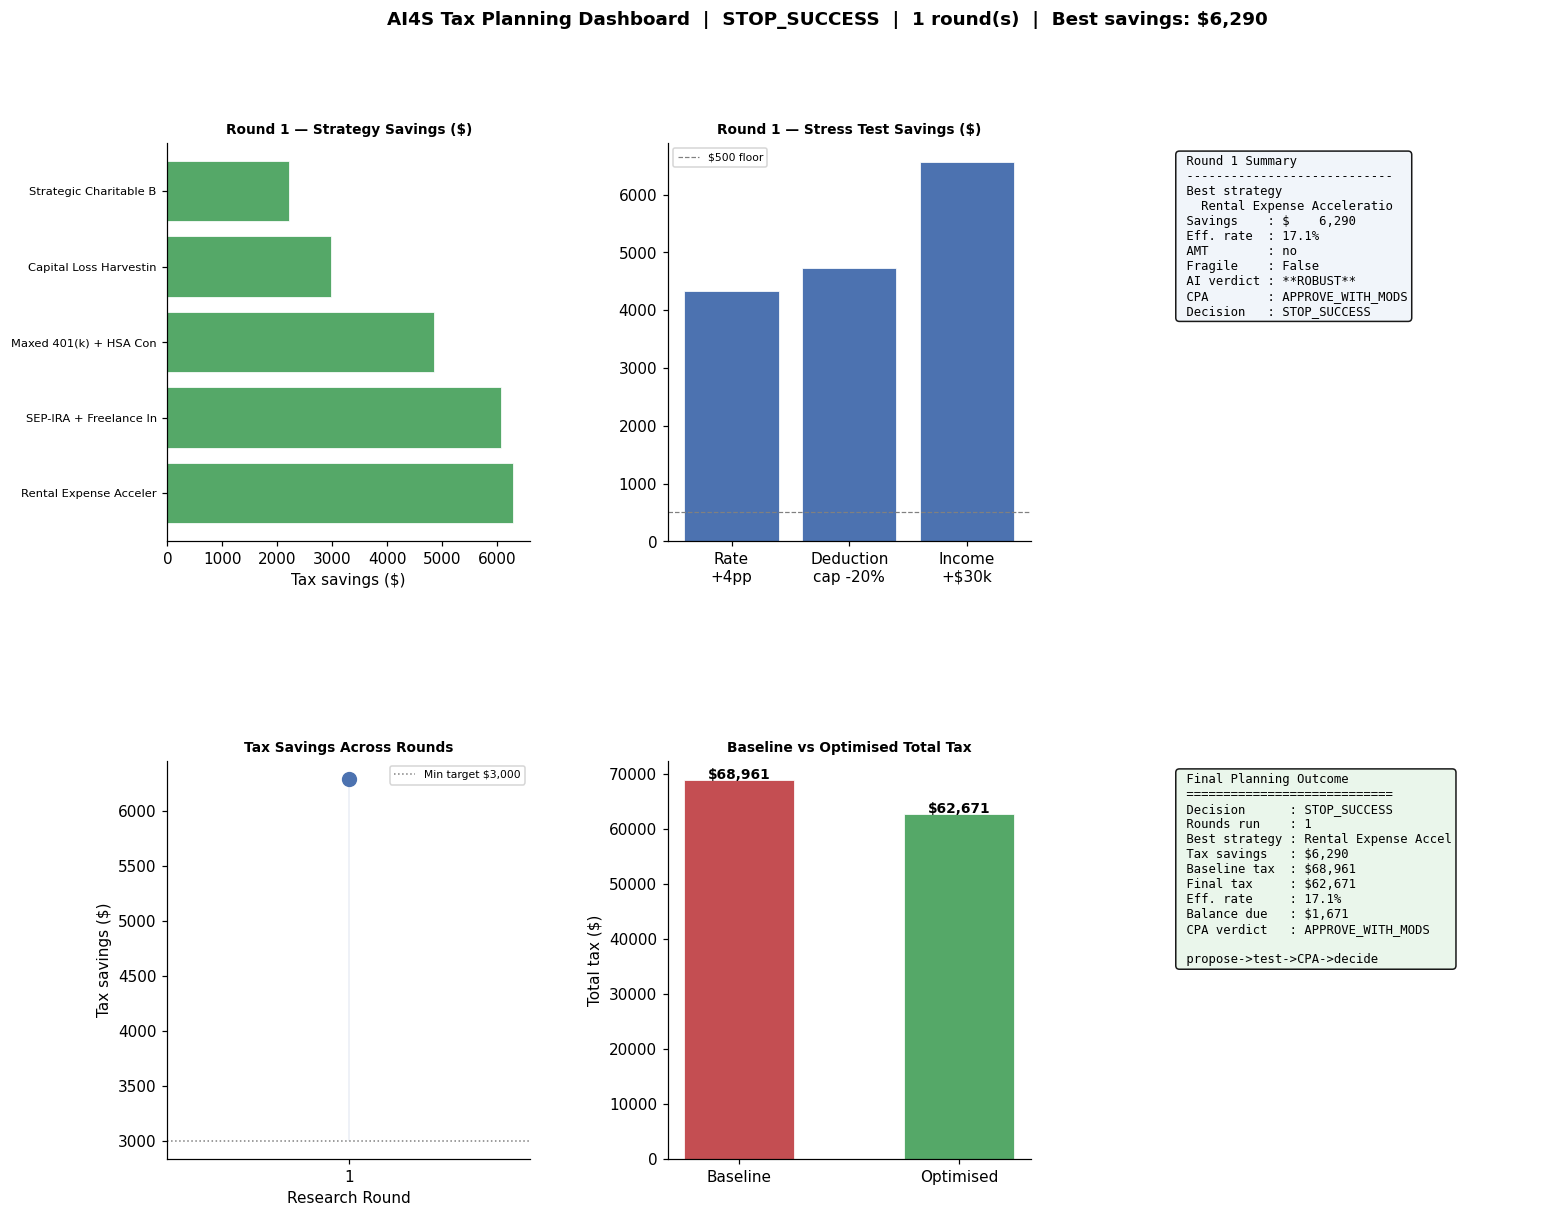

Dashboard saved: ai4s_tax_dashboard.png

  CLIENT MEMO

How to explain this to Alex & Jordan:
  > Jordan's 401(k) increase to $23,000 is a straightforward win—it's within IRS limits, reduces your taxable income by $15,000, and carries virtually no audit risk. We'll process this immediately.
  > On the rental property improvements, I want to be conservative on your behalf. The IRS closely scrutinizes the line between repairs (immediately deductible) and improvements (must be spread over years). Before we claim the $3,500, I need you to pull receipts and invoices so we can confidently defend each dollar. If documentation is solid, we can claim it all; if it's mixed, we'll claim only the repairs we can clearly substantiate—still a nice deduction with zero risk.
  > Your stated preference is to stay out of audit territory. Claiming well-documented repairs accomplishes that goal. Ambiguous expenses—even if technically defensible—create stress and potential headaches that aren't worth the ex

In [10]:
# CELL 9  FINAL REPORT DASHBOARD
# -----------------------------------------------------------------------

import matplotlib.gridspec as gridspec

n_rounds = len(agent.round_results)
fig = plt.figure(figsize=(16, 6 * n_rounds + 6))
gs  = gridspec.GridSpec(n_rounds + 1, 3, figure=fig,
                        hspace=0.55, wspace=0.38)
colors = plt.cm.tab10.colors

# -- per-round panels --------------------------------------------------
for ri, r in enumerate(agent.round_results):
    dec  = agent.decision_log[ri] if ri < len(agent.decision_log) else {}
    rev  = agent.cpa_reviews[ri]  if ri < len(agent.cpa_reviews)  else {}

    # savings bar chart
    ax1 = fig.add_subplot(gs[ri, 0])
    names   = [sr['strategy']['name'][:22] for sr in r.simulation_results]
    savings = [max(sr['savings'],0) for sr in r.simulation_results]
    bar_c   = ['#55A868' if sr['legal'] else '#C44E52'
               for sr in r.simulation_results]
    bars = ax1.barh(names, savings, color=bar_c, edgecolor='white', linewidth=0.5)
    ax1.axvline(0, color='black', lw=0.5)
    ax1.set_title(f'Round {r.cycle_num} — Strategy Savings ($)',
                  fontweight='bold', fontsize=9)
    ax1.set_xlabel('Tax savings ($)')
    ax1.tick_params(axis='y', labelsize=7.5)

    # stress test chart
    ax2 = fig.add_subplot(gs[ri, 1])
    sc_labels = ['Rate\n+4pp', 'Deduction\ncap -20%', 'Income\n+$30k']
    sc_vals   = [r.stress_results.get(k,{}).get('savings',0)
                 for k in ['rate_increase','deduction_cap','income_spike']]
    sc_colors = ['#4C72B0' if v > 500 else '#C44E52' for v in sc_vals]
    ax2.bar(sc_labels, sc_vals, color=sc_colors, edgecolor='white', linewidth=0.5)
    ax2.axhline(500, color='grey', ls='--', lw=0.8, label='$500 floor')
    ax2.set_title(f'Round {r.cycle_num} — Stress Test Savings ($)',
                  fontweight='bold', fontsize=9)
    ax2.legend(fontsize=7)

    # round summary text
    ax3 = fig.add_subplot(gs[ri, 2])
    ax3.axis('off')
    cpa_v   = rev.get('verdict','N/A')
    dec_v   = dec.get('decision','N/A')
    fb_tag  = r.feedback_verdict.splitlines()[-1] if r.feedback_verdict else 'N/A'
    best_res = r.best_result
    eff_rate = f'{best_res.effective_rate:.1%}' if best_res else 'N/A'
    amt_tag  = 'YES' if (best_res and best_res.amt_triggered) else 'no'
    txt = '\n'.join([
        f' Round {r.cycle_num} Summary',
        ' ' + '-'*28,
        f' Best strategy',
        f'   {r.best_strategy.get("name","?")[:26]}',
        f' Savings    : ${r.best_savings:>9,.0f}',
        f' Eff. rate  : {eff_rate}',
        f' AMT        : {amt_tag}',
        f' Fragile    : {r.fragile}',
        f' AI verdict : {fb_tag}',
        f' CPA        : {cpa_v}',
        f' Decision   : {dec_v}',
    ])
    ax3.text(0.03, 0.97, txt, transform=ax3.transAxes,
             fontsize=8, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f4fa', alpha=0.9))

# -- summary row -------------------------------------------------------
rounds  = [r.cycle_num      for r in agent.round_results]
savings = [r.best_savings   for r in agent.round_results]

axS1 = fig.add_subplot(gs[n_rounds, 0])
axS1.plot(rounds, savings, 'o-', color='#4C72B0', lw=2, ms=9)
axS1.axhline(agent.MIN_SAVINGS, color='grey', ls=':', lw=1,
             label=f'Min target ${agent.MIN_SAVINGS:,}')
axS1.fill_between(rounds, savings, agent.MIN_SAVINGS,
                  alpha=0.12, color='#4C72B0')
axS1.set_title('Tax Savings Across Rounds', fontweight='bold', fontsize=9)
axS1.set_xlabel('Research Round')
axS1.set_ylabel('Tax savings ($)')
axS1.set_xticks(rounds)
axS1.legend(fontsize=7)

# baseline vs best comparison
axS2 = fig.add_subplot(gs[n_rounds, 1])
best_r = best_result
cats  = ['Baseline', 'Optimised']
vals  = [baseline.total_tax,
          best_r.best_result.total_tax if best_r.best_result else baseline.total_tax]
bcolors = ['#C44E52', '#55A868']
axS2.bar(cats, vals, color=bcolors, width=0.5,
         edgecolor='white', linewidth=0.5)
axS2.set_title('Baseline vs Optimised Total Tax',
               fontweight='bold', fontsize=9)
axS2.set_ylabel('Total tax ($)')
for i, v in enumerate(vals):
    axS2.text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9,
              fontweight='bold')

# final verdict
axS3 = fig.add_subplot(gs[n_rounds, 2])
axS3.axis('off')
br   = best_result
brev = best_review
final_res = br.best_result
verdict_lines = [
    ' Final Planning Outcome',
    ' ' + '='*28,
    f' Decision      : {agent.final_decision}',
    f' Rounds run    : {n_rounds}',
    f' Best strategy : {br.best_strategy.get("name","?")[:20]}',
    f' Tax savings   : ${br.best_savings:,.0f}',
    f' Baseline tax  : ${baseline.total_tax:,.0f}',
    f' Final tax     : ${final_res.total_tax:,.0f}' if final_res else '',
    f' Eff. rate     : {final_res.effective_rate:.1%}' if final_res else '',
    f' Balance due   : ${final_res.balance_due:,.0f}' if final_res else '',
    f' CPA verdict   : {brev.get("verdict","N/A")}',
    '',
    ' propose->test->CPA->decide',
]
axS3.text(0.03, 0.97, '\n'.join(verdict_lines),
          transform=axS3.transAxes, fontsize=8, va='top',
          fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.9))

fig.suptitle(
    f'AI4S Tax Planning Dashboard  |  {agent.final_decision}  '
    f'|  {n_rounds} round(s)  |  Best savings: ${best_result.best_savings:,.0f}',
    fontsize=12, fontweight='bold'
)
plt.savefig('ai4s_tax_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print('Dashboard saved: ai4s_tax_dashboard.png')

# -- Print client memo -------------------------------------------------
print('\n' + '='*58)
print('  CLIENT MEMO')
print('='*58)
if brev.get('client_talking_points'):
    print('\nHow to explain this to Alex & Jordan:')
    for p in brev['client_talking_points']:
        print(f'  > {p}')
if brev.get('modifications'):
    print('\nModifications required before filing:')
    for m in brev['modifications']:
        print(f'  * {m}')

##3.CONCLUSIONS



This notebook demonstrates a governance-first approach to AI-assisted tax planning. Rather than treating artificial intelligence as a simple answer engine, the model organizes AI, deterministic computation, legal review, stress testing, and human-style professional judgment into a structured advisory architecture. The result is not merely a tax recommendation, but a controlled discovery process in which every proposed strategy must pass through multiple layers of validation before it can be considered acceptable.

At the center of the notebook is the idea that tax planning should not be optimized only for numerical savings. A strategy that reduces tax liability may still be unsuitable if it is legally fragile, difficult to explain, inconsistent with the taxpayer’s preferences, exposed to audit risk, or unstable under stress conditions. For that reason, the model separates the creative role of the language model from the computational and governance functions of the system. Claude is used to generate candidate strategies, perform structured legal review, provide feedback, and simulate a skeptical CPA review. However, the actual tax impact is calculated by the deterministic `compute_tax()` engine. This distinction is critical. It prevents the model from relying on free-form AI judgment for numerical outcomes and preserves a clear audit trail for every result.

The notebook also illustrates the value of agentic design. The TaxOptimizationLoop performs the operational search for strategies, while the HumanAdvisorAgent introduces professional skepticism and client suitability review. Above both sits the TaxEvaluationAgent, which determines whether the process should continue, stop successfully, or terminate after the maximum number of rounds. This layered architecture reflects an important principle of AI4S: intelligent systems should be governed by explicit procedures, not by unstructured model output alone.

The multi-round structure is especially important. Tax planning is rarely solved perfectly in one attempt. Strategies may fail legal review, underperform in simulation, become fragile under stress tests, or be rejected by a human advisor. By capturing failure context and using it to inform the next round, the notebook models a disciplined learning loop. The system does not simply produce an answer; it improves through structured iteration.

The dashboard and decision log complete the governance architecture by making the process visible. They show which strategies were generated, how much tax they saved, whether they passed legal gates, how they performed under stress, and how the CPA-style review influenced the final decision. This transforms the notebook from a black-box AI exercise into a reviewable advisory workflow.

Overall, the model should be understood as an agent-governed tax-planning discovery system. Its purpose is not to replace professional judgment, but to augment it with systematic search, reproducible simulation, explicit governance, and structured review. In practical terms, this architecture offers a template for responsible AI deployment in tax, accounting, and advisory services. It shows how AI can expand the range of strategies considered while preserving accountability, explainability, and human oversight. The central lesson is clear: in high-stakes professional domains, the future of AI is not automation without governance, but intelligence embedded inside auditable, disciplined, and professionally supervised systems.
